# ch234 — Numerical Differentiation and Gradient Checking

**Advanced Calculus Experiment 4.**

Gradient checking is one of the most practical debugging tools in deep learning. Any time you implement backpropagation *(ch216)* by hand, you should verify your analytical gradient against a numerical estimate. This experiment builds a production-quality gradient checker.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def numerical_gradient(f, x, h=1e-5):
    grad = np.zeros_like(x, dtype=float)
    it = np.nditer(x, flags=['multi_index'])
    while not it.finished:
        idx = it.multi_index
        x_plus  = x.copy(); x_plus[idx]  += h
        x_minus = x.copy(); x_minus[idx] -= h
        grad[idx] = (f(x_plus) - f(x_minus)) / (2*h)
        it.iternext()
    return grad

def gradient_check(f, analytical_grad_fn, x, threshold=1e-5):
    anal = analytical_grad_fn(x)
    numer = numerical_gradient(f, x)
    rel_err = np.linalg.norm(anal - numer) / (np.linalg.norm(anal) + np.linalg.norm(numer) + 1e-8)
    status = 'PASS' if rel_err < threshold else 'FAIL'
    return status, rel_err, anal, numer

print("Gradient checker ready.")

Gradient checker ready.


In [2]:
# Test 1: Simple quadratic
def f1(w): return np.sum(w**2) + 2*w[0]*w[1]
def grad_f1(w): return np.array([2*w[0] + 2*w[1], 2*w[1] + 2*w[0]])

x1 = np.array([1.5, -2.3])
status, err, anal, numer = gradient_check(f1, grad_f1, x1)
print(f"Test 1 (quadratic): {status}  rel_err={err:.2e}")

# Test 2: Buggy gradient (forgot normalisation factor)
def f2(w): return np.mean(w**2)
def buggy_grad_f2(w): return 2*w  # missing 1/n factor

status2, err2, anal2, numer2 = gradient_check(f2, buggy_grad_f2, x1)
print(f"Test 2 (buggy 1/n): {status2}  rel_err={err2:.2e}")
print("  Expected FAIL because analytical grad is missing 1/n factor")

# Correct version
def correct_grad_f2(w): return 2*w/len(w)
status3, err3, _, _ = gradient_check(f2, correct_grad_f2, x1)
print(f"Test 3 (corrected): {status3}  rel_err={err3:.2e}")

Test 1 (quadratic): PASS  rel_err=1.39e-11
Test 2 (buggy 1/n): FAIL  rel_err=3.33e-01
  Expected FAIL because analytical grad is missing 1/n factor
Test 3 (corrected): PASS  rel_err=6.15e-12


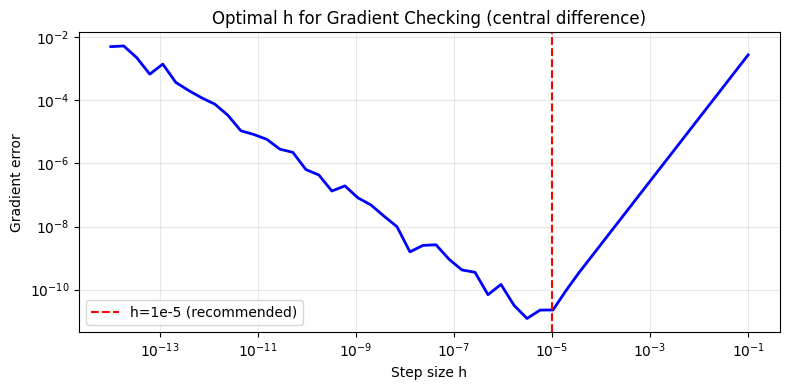

In [3]:
# Optimal step size h for gradient checking
f_test = lambda x: np.sin(x[0]) * np.exp(x[1])
grad_exact = lambda x: np.array([np.cos(x[0]) * np.exp(x[1]),
                                   np.sin(x[0]) * np.exp(x[1])])

x0 = np.array([1.2, 0.5])
true_g = grad_exact(x0)

h_vals = np.logspace(-14, -1, 50)
errors = [np.linalg.norm(numerical_gradient(f_test, x0, h=h) - true_g) for h in h_vals]

plt.figure(figsize=(8, 4))
plt.loglog(h_vals, errors, 'b-', lw=2)
plt.xlabel('Step size h'); plt.ylabel('Gradient error')
plt.title('Optimal h for Gradient Checking (central difference)')
plt.axvline(1e-5, color='red', ls='--', label='h=1e-5 (recommended)')
plt.legend(); plt.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.savefig('ch234_grad_check.png', dpi=100); plt.show()

## Summary

| Practice | Rule |
|---|---|
| Always gradient check new layers | Before training |
| Use h=1e-5 for float64 | Optimal for central difference |
| Relative error < 1e-5 | PASS threshold |
| Test all parameters | Not just a few |

**Forward reference:** ch291 — Optimisation Methods (Part IX) applies these debugging practices to real-world model training.